In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 300

hours_studied = np.random.uniform(0, 15, n_samples)
attendance = np.random.uniform(0, 100, n_samples)

labels = []

for h, a in zip(hours_studied, attendance):
    if h < 5:
        labels.append(0)  # Fail
    else:
        if a > 75:
            labels.append(1)  # Pass
        else:
            if h > 10:
                labels.append(1)  # Pass
            else:
                labels.append(0)  # Fail

labels = np.array(labels)

# 10 % Noise
noise_indices = np.random.choice(
    n_samples,
    size=int(0.1 * n_samples),
    replace=False
)

labels[noise_indices] = 1 - labels[noise_indices]

df = pd.DataFrame({
    "hours_studied": hours_studied,
    "attendance": attendance,
    "pass": labels
})

df.head()

,hours_studied,attendance,pass
0,5.618102,5.168172,0
1,14.260715,53.135463,1
2,10.979909,54.063512,1
3,8.979877,63.742990,0
4,2.340280,72.609133,0


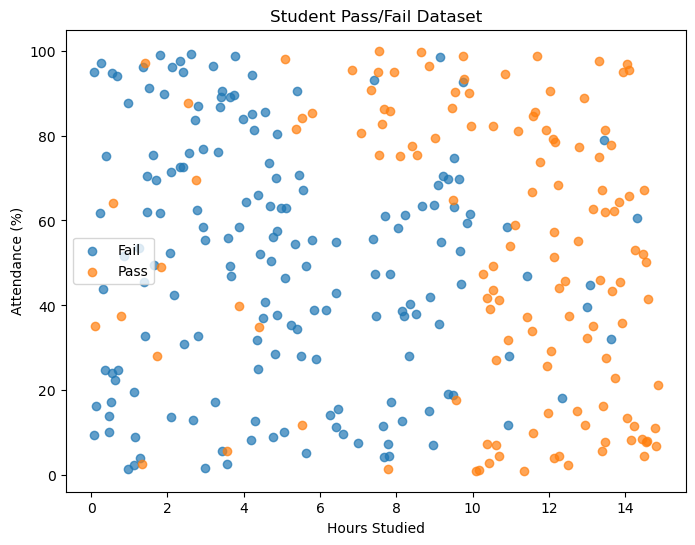

In [3]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df["pass"] == 0]["hours_studied"],
    df[df["pass"] == 0]["attendance"],
    label="Fail",
    alpha=0.7
)

plt.scatter(
    df[df["pass"] == 1]["hours_studied"],
    df[df["pass"] == 1]["attendance"],
    label="Pass",
    alpha=0.7
)

plt.xlabel("Hours Studied")
plt.ylabel("Attendance (%)")
plt.title("Student Pass/Fail Dataset")
plt.legend()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df[["hours_studied", "attendance"]]
y = df["pass"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

depths = [1, 3, None]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    print("max_depth:", depth)
    print("Train Accuracy:", accuracy_score(y_train, train_pred))
    print("Test Accuracy:", accuracy_score(y_test, test_pred))
    print("Tree Depth:", model.get_depth())
    print("Number of Leaves:", model.get_n_leaves())
    print("-" * 40)

max_depth: 1
Train Accuracy: 0.8380952380952381
Test Accuracy: 0.8
Tree Depth: 1
Number of Leaves: 2
----------------------------------------
max_depth: 3
Train Accuracy: 0.9047619047619048
Test Accuracy: 0.8777777777777778
Tree Depth: 3
Number of Leaves: 7
----------------------------------------
max_depth: None
Train Accuracy: 1.0
Test Accuracy: 0.7111111111111111
Tree Depth: 14
Number of Leaves: 42
----------------------------------------


In [5]:
def plot_decision_boundary(model, X, y, title):
    h = 0.1

    x_min, x_max = X["hours_studied"].min() - 1, X["hours_studied"].max() + 1
    y_min, y_max = X["attendance"].min() - 5, X["attendance"].max() + 5

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid = pd.DataFrame({
        "hours_studied": xx.ravel(),
        "attendance": yy.ravel()
    })

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(
        X[y == 0]["hours_studied"],
        X[y == 0]["attendance"],
        label="Fail",
        alpha=0.7
    )

    plt.scatter(
        X[y == 1]["hours_studied"],
        X[y == 1]["attendance"],
        label="Pass",
        alpha=0.7
    )

    plt.xlabel("Hours Studied")
    plt.ylabel("Attendance (%)")
    plt.title(title)
    plt.legend()
    plt.show()

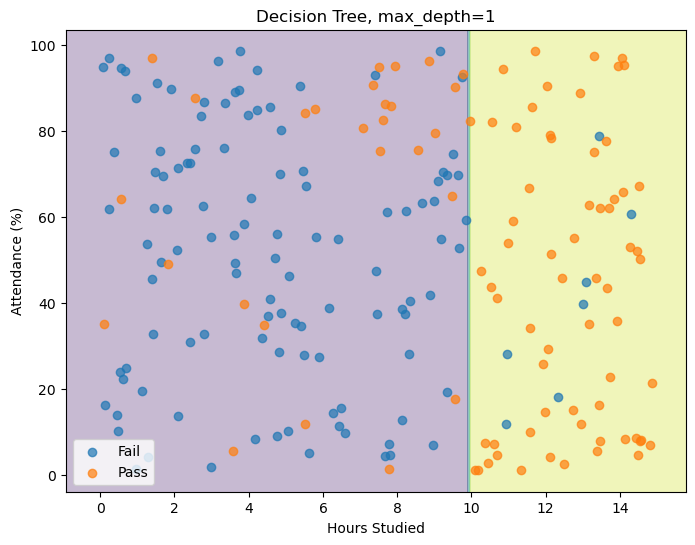

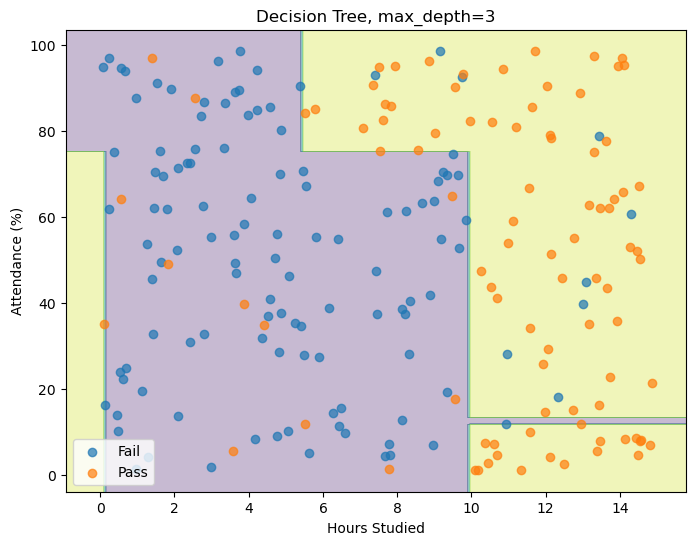

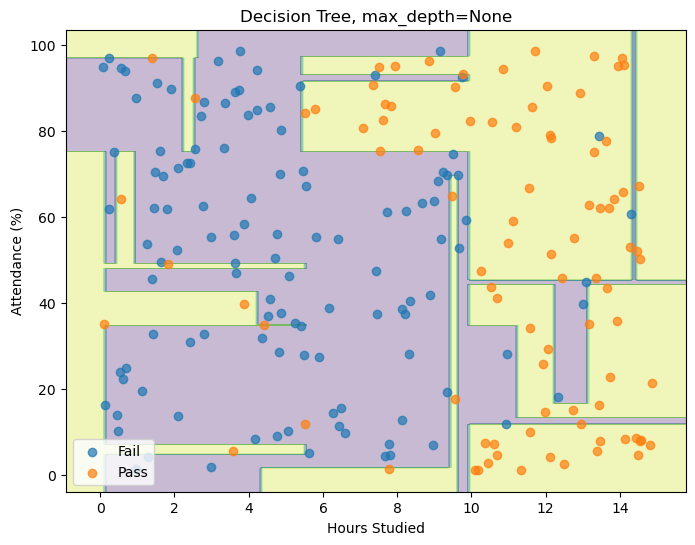

In [7]:
for depth in [1, 3, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    plot_decision_boundary(
        model,
        X_train,
        y_train,
        title=f"Decision Tree, max_depth={depth}"
    )

n_estimators: 1
Train Accuracy: 0.9285714285714286
Test Accuracy: 0.7222222222222222
----------------------------------------


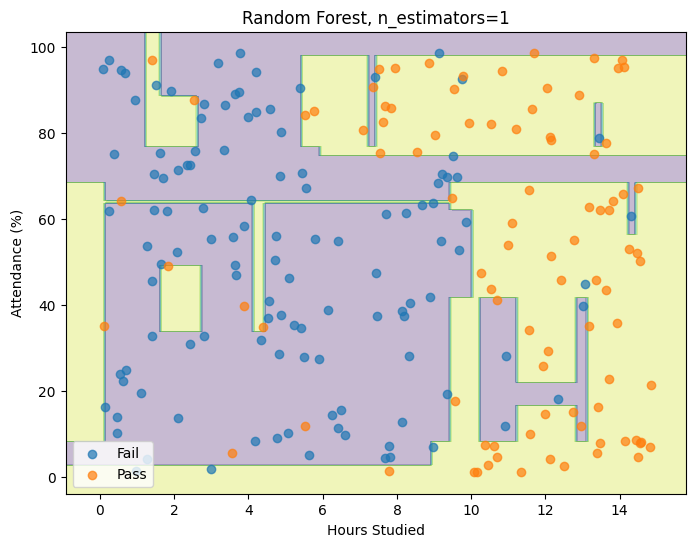

n_estimators: 5
Train Accuracy: 0.9857142857142858
Test Accuracy: 0.8111111111111111
----------------------------------------


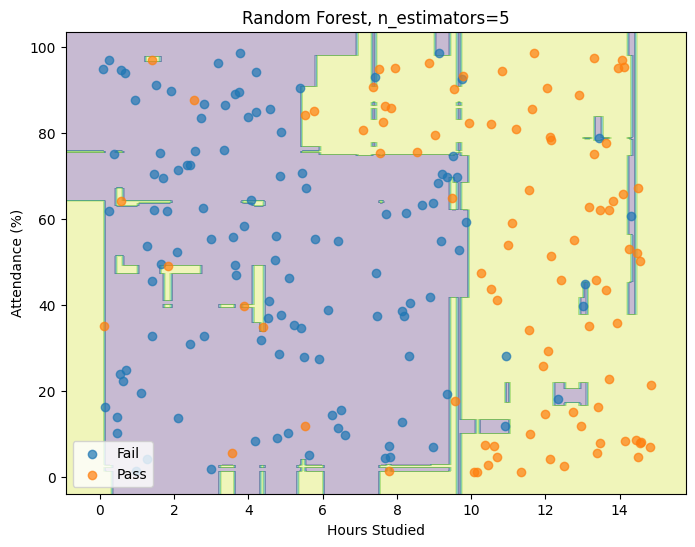

n_estimators: 100
Train Accuracy: 1.0
Test Accuracy: 0.8666666666666667
----------------------------------------


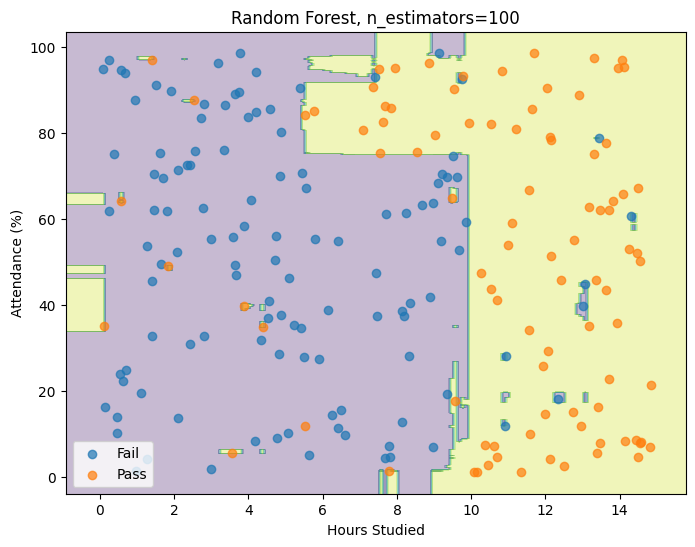

In [ ]:
from sklearn.ensemble import RandomForestClassifier

for n in [1, 5, 100]:
    rf = RandomForestClassifier(
        n_estimators=n,
        max_features="sqrt",
        random_state=42
    )

    rf.fit(X_train, y_train)

    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)

    print("n_estimators:", n)
    print("Train Accuracy:", accuracy_score(y_train, train_pred))
    print("Test Accuracy:", accuracy_score(y_test, test_pred))
    print("-" * 40)

    plot_decision_boundary(
        rf,
        X_train,
        y_train,
        title=f"Random Forest, n_estimators={n}"
    )

In [ ]:
configs = [
    {"n_estimators": 100, "max_depth": 1, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": 3, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "max_features": 2, "min_samples_leaf": 1},
    {"n_estimators": 100, "max_depth": None, "max_features": "sqrt", "min_samples_leaf": 10},
]

results = []

for config in configs:
    rf = RandomForestClassifier(
        **config,
        random_state=42
    )

    rf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc = accuracy_score(y_test, rf.predict(X_test))

    results.append({
        **config,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

rf_results = pd.DataFrame(results)
rf_results

,n_estimators,max_depth,max_features,min_samples_leaf,train_accuracy,test_accuracy
0,100,1.0,sqrt,1,0.838095,0.800000
1,100,3.0,sqrt,1,0.890476,0.877778
2,100,NaN,sqrt,1,1.000000,0.866667
3,100,NaN,2,1,1.000000,0.822222
4,100,NaN,sqrt,10,0.895238,0.877778


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    random_state=42
)

rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
})

feature_importance

,feature,importance
0,hours_studied,0.715333
1,attendance,0.284667


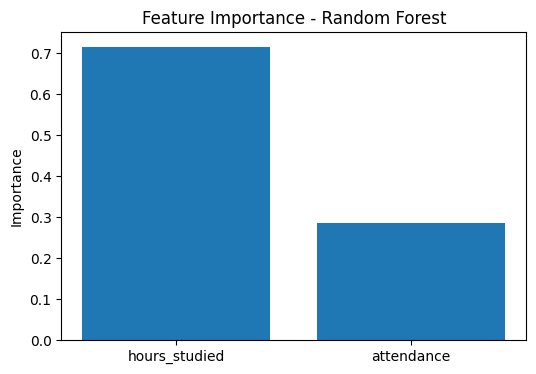

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.ylabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.show()

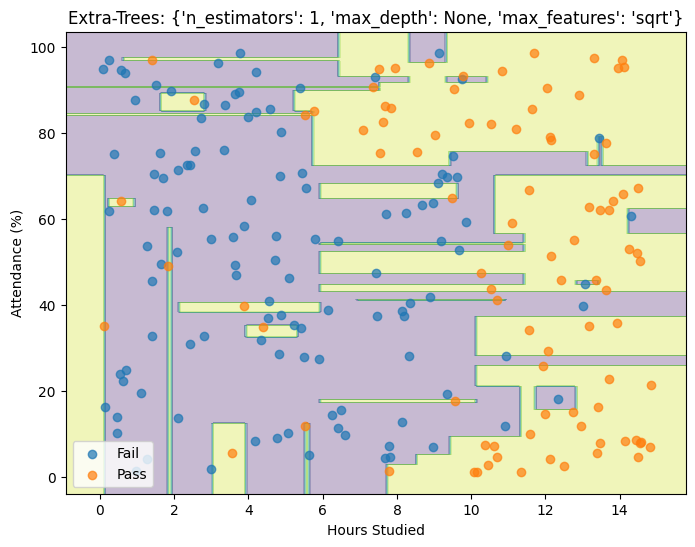

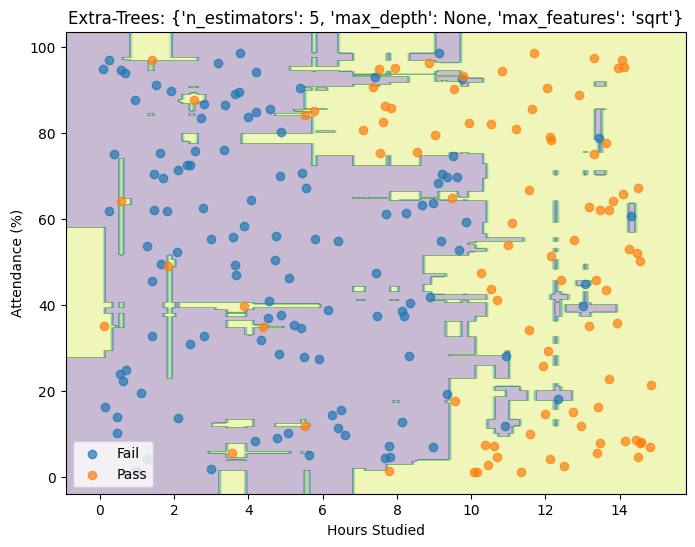

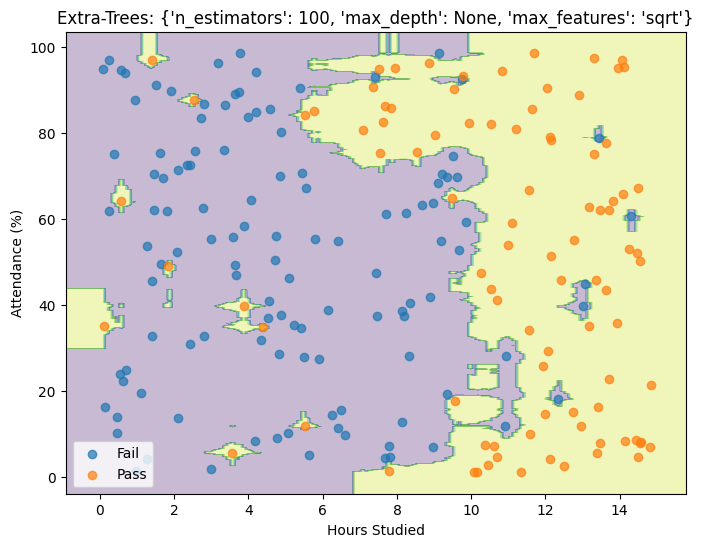

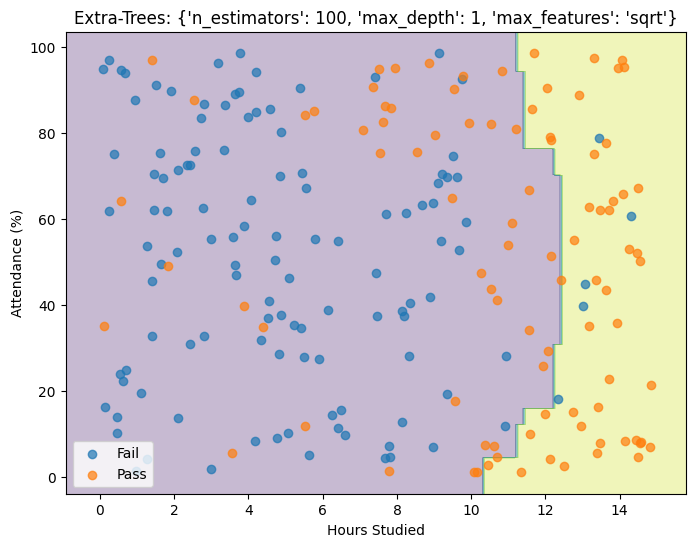

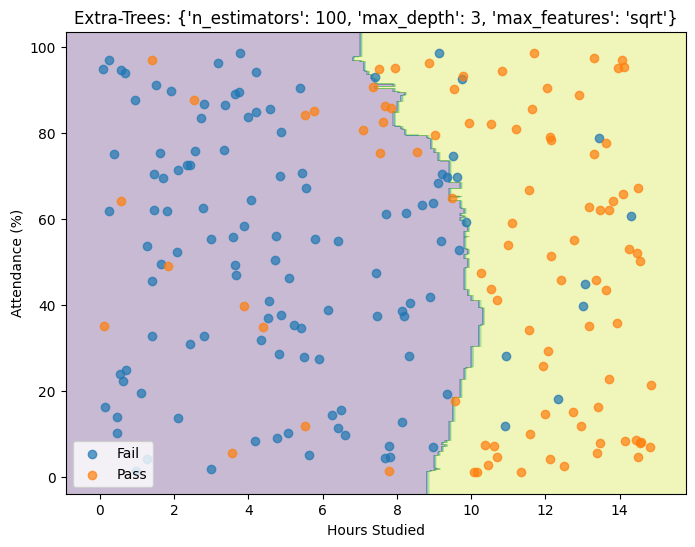

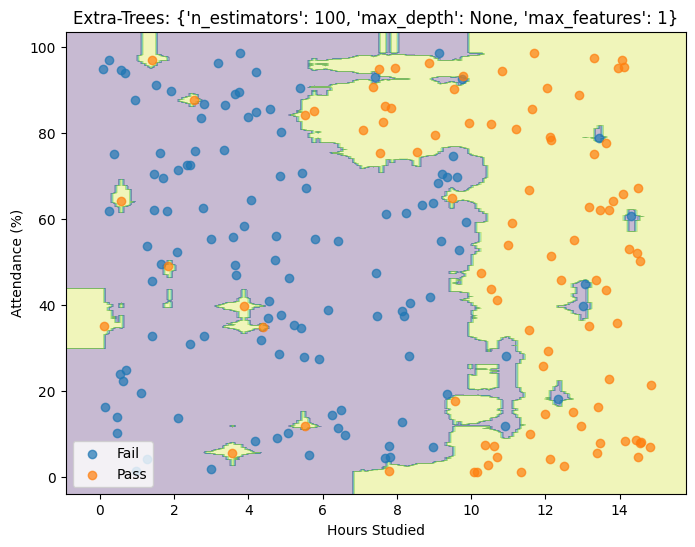

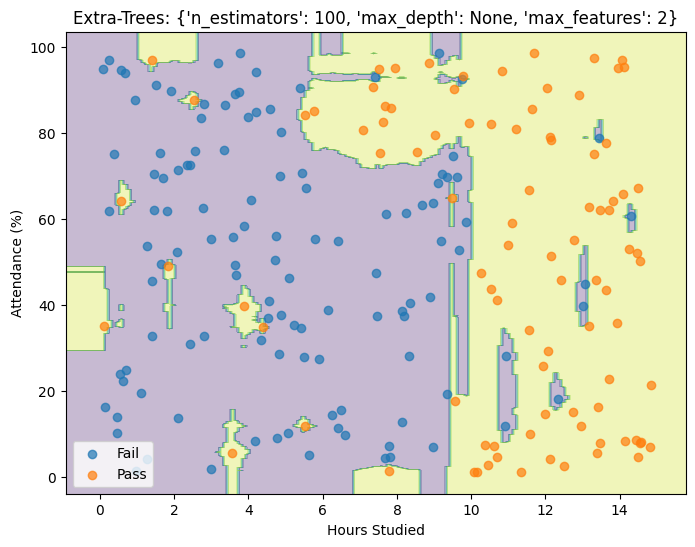

,n_estimators,max_depth,max_features,train_accuracy,test_accuracy
0,1,NaN,sqrt,1.000000,0.744444
1,5,NaN,sqrt,1.000000,0.788889
2,100,NaN,sqrt,1.000000,0.811111
3,100,1.0,sqrt,0.752381,0.722222
4,100,3.0,sqrt,0.847619,0.855556
5,100,NaN,1,1.000000,0.811111
6,100,NaN,2,1.000000,0.788889


In [ ]:
from sklearn.ensemble import ExtraTreesClassifier

extra_configs = [
    {"n_estimators": 1, "max_depth": None, "max_features": "sqrt"},
    {"n_estimators": 5, "max_depth": None, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": None, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 1, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": 3, "max_features": "sqrt"},
    {"n_estimators": 100, "max_depth": None, "max_features": 1},
    {"n_estimators": 100, "max_depth": None, "max_features": 2},
]

extra_results = []

for config in extra_configs:
    et = ExtraTreesClassifier(
        **config,
        random_state=42
    )

    et.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, et.predict(X_train))
    test_acc = accuracy_score(y_test, et.predict(X_test))

    extra_results.append({
        **config,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc
    })

    plot_decision_boundary(
        et,
        X_train,
        y_train,
        title=f"Extra-Trees: {config}"
    )

extra_results = pd.DataFrame(extra_results)
extra_results

In [ ]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        max_features="sqrt",
        random_state=42
    ),
    "Extra-Trees": ExtraTreesClassifier(
        n_estimators=100,
        max_depth=None,
        max_features="sqrt",
        random_state=42
    )
}

comparison = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    comparison.append({
        "model": name,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "overfitting_gap": train_acc - test_acc
    })

comparison_df = pd.DataFrame(comparison)
comparison_df.sort_values("test_accuracy", ascending=False)

,model,train_accuracy,test_accuracy,overfitting_gap
0,Decision Tree,0.904762,0.877778,0.026984
1,Random Forest,1.000000,0.866667,0.133333
2,Extra-Trees,1.000000,0.811111,0.188889
